In [160]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [161]:
def swissRoll(samples=1024, noise=0.5):
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    x = t * tf.math.cos(t)
    y = t * tf.math.sin(t)
    X = tf.concat([x, y], axis=1)
    if noise > 0:
        X += noise * tf.random.normal(shape=(samples, 2))
    return X

In [162]:
batch_size = 1024
train_data = swissRoll(samples=100000, noise=0.5)
dataset = tf.data.Dataset.from_tensor_slices(train_data).shuffle(10000).batch(batch_size)

In [163]:
print(train_data.shape)

(100000, 2)


In [164]:
print(dataset)

<_BatchDataset element_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)>


In [165]:
noise_inputs = tf.random.normal(shape=(100000, 2))

In [166]:
naive_model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(2)
], name="Naive")

In [167]:
naive_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

In [168]:
print("Training the Naive Model...")
naive_history = naive_model.fit(
    x=noise_inputs,
    y=train_data,
    batch_size=1024,
    epochs=10
)

Training the Naive Model...
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 47.5983
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 46.4439
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 46.2593
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.2523
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 46.2417
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.2537
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.2369
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.2301
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.2323
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 46.2325


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


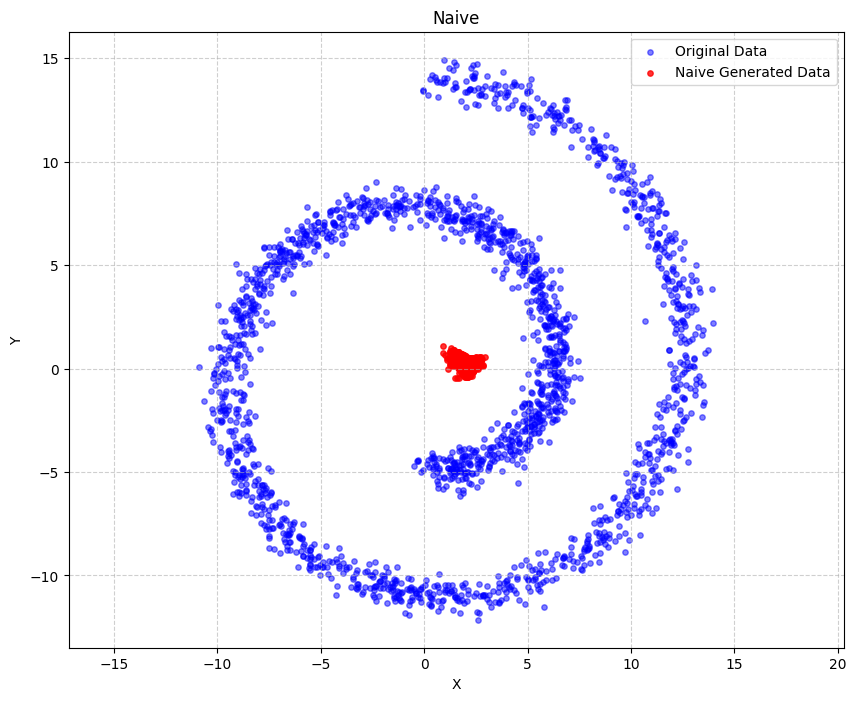

In [169]:
test_noise = tf.random.normal(shape=(2000, 2))
naive_generated_data = naive_model.predict(test_noise)

plt.figure(figsize=(10, 8))

original_subset = train_data[:2000]
plt.scatter(original_subset[:, 0], original_subset[:, 1],
            alpha=0.5, label='Original Data', c='blue', s=15)

plt.scatter(naive_generated_data[:, 0], naive_generated_data[:, 1],
            alpha=0.8, label='Naive Generated Data', c='red', s=15)

plt.title("Naive")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

In [170]:
class Sampling(tf.keras.layers.Layer):
    def call(self, latent):
        mean = latent[:, :2]
        logVar = latent[:, 2:]

        batch = tf.shape(mean)[0]
        dim = tf.shape(mean)[1]
        gaussian_noise = tf.keras.backend.random_normal(shape=(batch, dim))

        std = tf.exp(0.5 * logVar)
        latentSample = mean + std * gaussian_noise

        return latentSample

In [171]:
latent_dim = 2

# ENCODER
encoder_inputs = tf.keras.Input(shape=(2,))
x = tf.keras.layers.Dense(64, activation='relu')(encoder_inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
latent = tf.keras.layers.Dense(latent_dim * 2, name="latent")(x)

latentSample = Sampling()(latent)

encoder = tf.keras.Model(encoder_inputs, [latent, latentSample], name="encoder")

# DECODER
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(64)(latent_inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
decoder_outputs = tf.keras.layers.Dense(2)(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sampling_9 (Sampling)           │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,124 (20.02 KB)

 Trainable params: 4,868 (19.02 KB)

 Non-trainable params: 256 (1.00 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,994 (19.51 KB)

 Trainable params: 4,738 (18.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [172]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:

            latent, latentSample = self.encoder(data)

            reconstruction = self.decoder(latentSample)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            mean = latent[:, :2]
            logVar = latent[:, 2:]

            kl = tf.square(mean) + tf.exp(logVar) - logVar

            kl_loss = tf.reduce_mean(tf.reduce_sum(kl, axis=1))

            beta = 0.1
            total_loss = reconstruction_loss + beta * kl_loss


        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))


        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [173]:
vae = VAE(encoder, decoder)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
vae.compile(optimizer=optimizer)

epochs = 10

print("Training the VAE...")
history = vae.fit(dataset, epochs=epochs)

Training the VAE...
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 49.5157 - loss: 27.1710 - reconstruction_loss: 22.2194
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 27.7586 - loss: 3.1747 - reconstruction_loss: 0.3988
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 19.1908 - loss: 2.2643 - reconstruction_loss: 0.3452
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 16.7700 - loss: 1.9752 - reconstruction_loss: 0.2982
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 15.6511 - loss: 1.8411 - reconstruction_loss: 0.2760
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 14.9441 - loss: 1.7565 - reconstruction_loss: 0.2621
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 14.4775 - loss: 1.6990 - reconstruction_loss: 0.2512
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - kl_loss: 14.1956 - loss: 1.6599 - reconstruction_loss: 0.2404
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - kl_lo

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


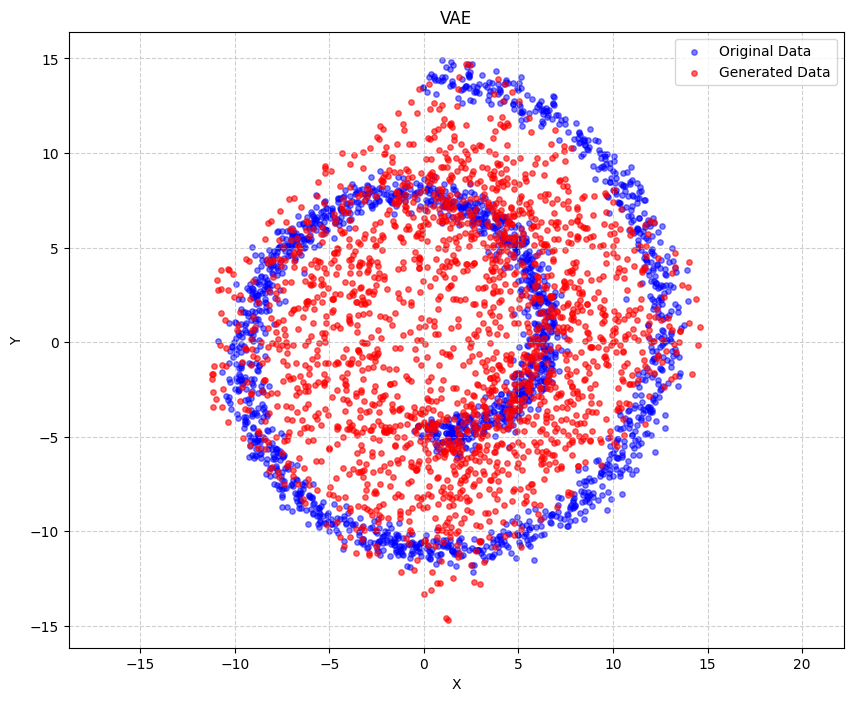

In [174]:
num_samples = 2000
latent_samples = tf.random.truncated_normal(shape=(num_samples, latent_dim), mean=0.0, stddev=1.0)
generated_data = vae.decoder.predict(latent_samples)

plt.figure(figsize=(10, 8))

original_subset = train_data[:num_samples]
plt.scatter(original_subset[:, 0], original_subset[:, 1],
            alpha=0.5, label='Original Data', c='blue', s=15)

plt.scatter(generated_data[:, 0], generated_data[:, 1],
            alpha=0.6, label='Generated Data', c='red', s=15)


plt.title("VAE")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

**Training for 300 epochs (29,400 steps) produced a much sharper and more accurate Swiss Roll than the 1,000-step limit, demonstrating the model's full potential.**

In [175]:
vae_300 = VAE(encoder, decoder)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
vae_300.compile(optimizer=optimizer)

epochs = 300

print("Training the VAE...")
history = vae_300.fit(dataset, epochs=epochs)

Training the VAE...
Epoch 1/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 14.0278 - loss: 1.7779 - reconstruction_loss: 0.3751
Epoch 2/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 13.9600 - loss: 1.6084 - reconstruction_loss: 0.2124
Epoch 3/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 13.9256 - loss: 1.6063 - reconstruction_loss: 0.2137
Epoch 4/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 13.8989 - loss: 1.6054 - reconstruction_loss: 0.2155
Epoch 5/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 13.8672 - loss: 1.6030 - reconstruction_loss: 0.2163
Epoch 6/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - kl_loss: 13.8625 - loss: 1.6021 - reconstruction_loss: 0.2159
Epoch 7/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - kl_loss: 13.8476 - loss: 1.5990 - reconstruction_loss: 0.2142
Epoch 8/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 13.8423 - loss: 1.5990 - reconstruction_loss: 0.2148
Epoch 9/300
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


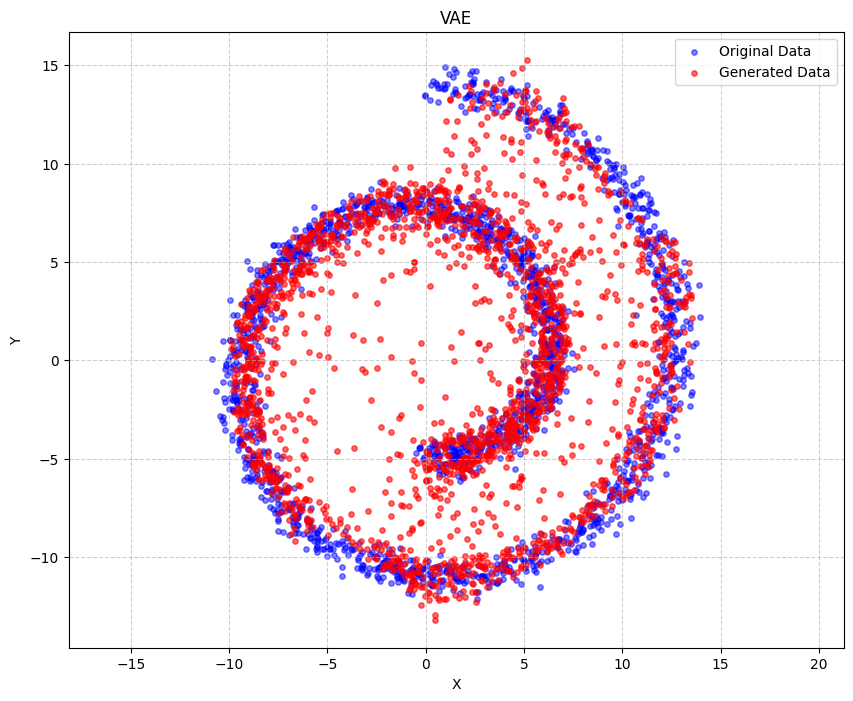

In [176]:
num_samples = 2000
latent_samples = tf.random.truncated_normal(shape=(num_samples, latent_dim), mean=0.0, stddev=1.0)
generated_data = vae_300.decoder.predict(latent_samples)

plt.figure(figsize=(10, 8))

original_subset = train_data[:num_samples]
plt.scatter(original_subset[:, 0], original_subset[:, 1],
            alpha=0.5, label='Original Data', c='blue', s=15)

plt.scatter(generated_data[:, 0], generated_data[:, 1],
            alpha=0.6, label='Generated Data', c='red', s=15)


plt.title("VAE")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()